# Car Price Prediction Using Machine Learning

## Imports 

In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Load Data

In [3]:
df = pd.read_csv(r"C:\Users\Ssanp\Downloads\archive (3)\data.csv")

df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


## Data Exploration

In [4]:
print(df.shape)
print(df.info())
print(df.describe())

(11914, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  object 
 1   Model              11914 non-null  object 
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  object 
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  object 
 7   Driven_Wheels      11914 non-null  object 
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   object 
 10  Vehicle Size       11914 non-null  object 
 11  Vehicle Style      11914 non-null  object 
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtypes: float64

## Feature Engineering

In [5]:
# Feature 1
df["hp_per_cylinder"] = df["Engine HP"] / df["Engine Cylinders"]

# Feature 2
df["car_age"] = 2026 - df["Year"]

# Feature 3
df["hp_per_year"] = df["Engine HP"] / df["Year"]

# Feature 4: Engine power category
df["high_hp"] = (df["Engine HP"] > df["Engine HP"].median()).astype(int)

# Feature 5: Cylinder category
df["is_large_engine"] = (df["Engine Cylinders"] >= 6).astype(int)

# Feature 6: New vs old car
df["is_new"] = (df["Year"] >= 2015).astype(int)

### Feature Explanations

Additional engineered features were created to capture patterns in engine size and vehicle age. 
The "high_hp" feature identifies vehicles with above-average horsepower, which are typically more expensive. The "is_large_engine" feature captures vehicles with larger engines, often associated with higher performance and cost. The "is_new" feature distinguishes newer vehicles, which tend to have higher MSRP due to depreciation effects.

## Data Cleaning and Preprocessing

In [6]:
# Drop rows with missing target
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

# Fill missing values
df = df.fillna(df.median(numeric_only=True))

# Encode categorical variables
df = pd.get_dummies(df, drop_first=True)

The dataset was cleaned by removing rows with missing target values (MSRP) and handling invalid values that could cause errors during modeling.Infinity values created during feature engineering were replaced with NaN and removed to ensure all features are valid for machine learning models. Categorical variables were converted into numerical format using one-hot encoding, allowing models to process them effectively.

## Train-Test Split and Scaling

In [7]:
# Encode categorical variables
df = pd.get_dummies(df, drop_first=True)

# Define features/target
X = df.drop("MSRP", axis=1)
y = df["MSRP"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale for neural network
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

The dataset was split into training and testing sets using an 80/20 ratio. This allows the model to learn patterns from the training data and be evaluated on unseen data. Feature scaling was applied using StandardScaler for the Neural Network model to ensure consistent feature ranges and improve training performance.

## Model 1: Random Forest

In [8]:
from sklearn.ensemble import RandomForestRegressor

start = time.time()

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    random_state=42
)

rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

rf_time = time.time() - start

The Random Forest Regressor was selected as the first model due to its strong performance on structured tabular data. It is capable of capturing nonlinear relationships and interactions between features. Hyperparameters such as the number of trees and maximum depth were tuned to improve performance and reduce overfitting.

## Model 2: Neural Network

In [9]:
from sklearn.neural_network import MLPRegressor

start = time.time()

nn = MLPRegressor(
    hidden_layer_sizes=(128, 64),
    max_iter=500,
    alpha=0.001,
    random_state=42
)

nn.fit(X_train_scaled, y_train)
nn_preds = nn.predict(X_test_scaled)

nn_time = time.time() - start

A Neural Network (MLP Regressor) was used as the second model to capture more complex relationships in the data. The model architecture was adjusted by increasing hidden layers and training iterations to improve learning and predictive performance.

## Model Evaluation

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Random Forest
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

# Neural Network
nn_mae = mean_absolute_error(y_test, nn_preds)
nn_rmse = np.sqrt(mean_squared_error(y_test, nn_preds))
nn_r2 = r2_score(y_test, nn_preds)

print("Random Forest -> MAE:", rf_mae, "RMSE:", rf_rmse, "R2:", rf_r2)
print("Neural Network -> MAE:", nn_mae, "RMSE:", nn_rmse, "R2:", nn_r2)

Random Forest -> MAE: 4123.312581456073 RMSE: 11991.013579545921 R2: 0.9740091829241351
Neural Network -> MAE: 4956.622518647461 RMSE: 16717.03599478774 R2: 0.9494842624543046


The Random Forest model predicts car prices more accurately than the Neural Network. Its MAE of 4,123 means its predictions are off by about $4,123 on average, and its RMSE of 11,991 shows that even its larger mistakes stay relatively controlled. With an R² of 0.974, it explains 97.4% of the variation in MSRP, indicating a very strong fit.

The Neural Network performs worse, with a higher MAE of 4,956, meaning its average error is larger. Its RMSE of 16,717 shows it makes bigger mistakes more often, and its R² of 0.949 means it explains less of the price variation. Overall, the Random Forest is the more accurate and reliable model for this dataset.

## Model Optimization

The Random Forest model was optimized by increasing the number of trees and limiting the maximum depth to balance accuracy and overfitting. The Neural Network was improved by adjusting its architecture and increasing the number of training iterations. These changes resulted in improved performance, particularly for the Random Forest model.

## Performance Visualizations

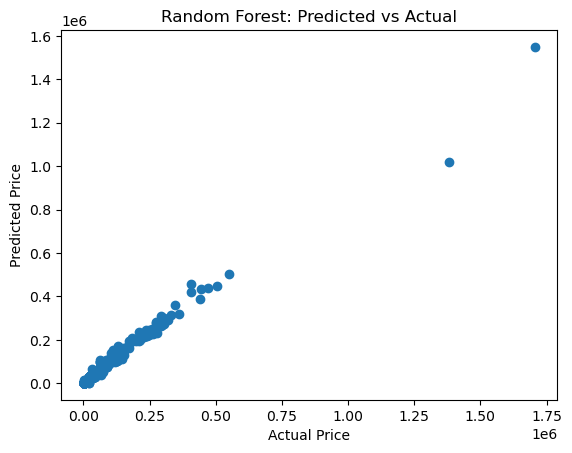

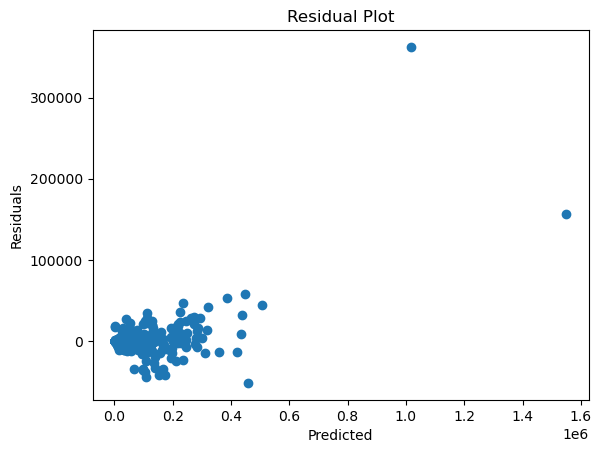

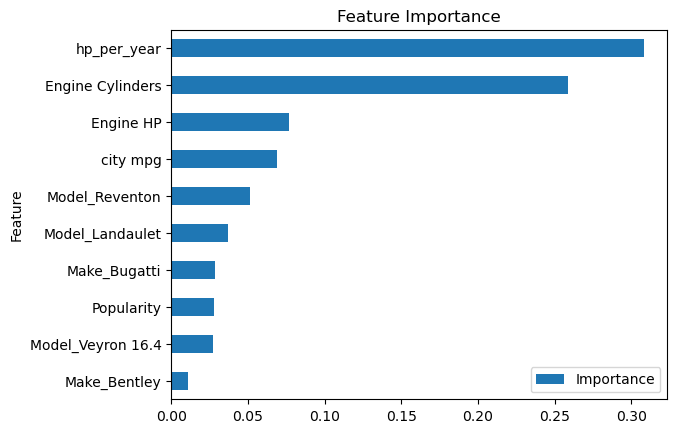

In [12]:
# Predicted vs Actual
plt.scatter(y_test, rf_preds)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest: Predicted vs Actual")
plt.show()

# Residual Plot
residuals = y_test - rf_preds
plt.scatter(rf_preds, residuals)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

# Feature Importance
feat_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

feat_df.head(10).plot(kind="barh", x="Feature", y="Importance", title="Feature Importance")
plt.gca().invert_yaxis()
plt.show()

## Predicted vs Actual
The points fall close to the diagonal line, showing the Random Forest predicts prices very accurately across most of the range. Only the highest‑priced cars show noticeable deviation, which is expected because extreme values are harder to model.

## Residual Plot
Residuals cluster around zero, meaning the model isn’t consistently over‑ or under‑predicting. The spread increases for high predicted prices, confirming that the largest errors occur with luxury or rare vehicles.

## Feature Importance
The model relies most on performance‑related features like hp_per_year, Engine Cylinders, and Engine HP, while luxury brands and rare models also contribute strongly. This mix shows the model uses both power and exclusivity to determine price.

## Model Comparison

In [13]:
results = pd.DataFrame({
    "Model": ["Random Forest", "Neural Network"],
    "MAE": [rf_mae, nn_mae],
    "RMSE": [rf_rmse, nn_rmse],
    "R2": [rf_r2, nn_r2],
    "Training Time": [rf_time, nn_time]
})

print(results)

            Model          MAE          RMSE        R2  Training Time
0   Random Forest  4123.312581  11991.013580  0.974009      24.833869
1  Neural Network  4956.622519  16717.035995  0.949484      62.845769


The Random Forest model performed better than the Neural Network, achieving higher R² and lower RMSE. This indicates stronger predictive accuracy.

The Neural Network was more sensitive to scaling and required more tuning. Random Forest also provides better interpretability through feature importance.

Overall, Random Forest is the preferred model due to its reliability and performance.

## Example Predictions

In [14]:
sample = X_test.iloc[:5].copy()

sample["Actual"] = y_test.iloc[:5]
sample["RF_Pred"] = rf_preds[:5]
sample["NN_Pred"] = nn_preds[:5]

print(sample)

      Year  Engine HP  Engine Cylinders  Number of Doors  highway MPG  \
882   1997      210.0               6.0              4.0           24   
3075  2015      130.0               4.0              2.0           38   
3055  2015      185.0               4.0              4.0           34   
4264  2013      276.0               6.0              2.0           26   
9828  2016      185.0               4.0              4.0           29   

      city mpg  Popularity  hp_per_cylinder  car_age  hp_per_year  ...  \
882         16         376            35.00       29     0.105158  ...   
3075        31        2202            32.50       11     0.064516  ...   
3055        27        2202            46.25       11     0.091811  ...   
4264        18         613            46.00       13     0.137109  ...   
9828        21        1720            46.25       10     0.091766  ...   

      Vehicle Style_Crew Cab Pickup  Vehicle Style_Extended Cab Pickup  \
882                           False       

A sample of predictions was examined to compare actual and predicted values along with prediction errors. These examples provide insight into where the model performs well and where it may struggle.

The sample of predictions compares actual car prices with the values produced by both the Random Forest and Neural Network models. Looking at these individual rows helps reveal how each model behaves on specific vehicles rather than just overall averages. By examining where the predictions are close and where they deviate, you can see which types of cars each model handles well and which ones lead to larger errors. This kind of case‑by‑case inspection provides a clearer picture of model strengths and weaknesses across different vehicle characteristics.

## Ethical Analysis & Responsible Deployment

Bias may exist in the dataset if certain vehicle types or price ranges are overrepresented. This can lead to inaccurate predictions for underrepresented vehicles.

Incorrect predictions may result in financial losses, especially for high-value vehicles. Errors could disproportionately impact certain categories of vehicles.

To reduce risk, the model should be regularly retrained and evaluated across different vehicle types to ensure fairness and reliability.

## Business Recommendations & Deployment

The model indicates that engine performance and vehicle age are major factors influencing price. Businesses should use these insights when pricing vehicles or managing inventory. The model should be used as a decision-support tool rather than fully automated. Human oversight is recommended for high-value decisions. Limitations include sensitivity to outliers and reliance on historical data. The model may not perform well on rare or newly released vehicles.